In [5]:
from collections import Counter
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skew
from scipy.stats import mode
import numpy as np
print('started')

started


# Finding the outliers

In [6]:
d=[1,2,3,4,5,6,7,8,9,10,170]
d.sort()

## Finding the mean median mode

### Python

In [19]:
mean=sum(d)/len(d)
q2=median=(d[len(d)//2-1]+d[len(d)//2])/2 if len(d)%2==0 else d[len(d)//2]
mode=[]
freq=Counter(d)
max_count=0
for count in freq.values():
    if count > max_count:
        max_count=count
for val,count in freq.items() if max_count>1 else []:
    if count==max_count:
        mode.append(val)
print(mean)
print(median)
print(mode)

20.454545454545453
6
[]


### NumPy

In [8]:
print(np.mean(d))
print(np.median(d))
print(stats.mode(d))

20.454545454545453
6.0
ModeResult(mode=np.int64(1), count=np.int64(1))


## Finding the Interquartile Range

In [9]:
fh=d[:len(d)//2]
sh=d[len(d)//2 if len(d)%2==0 else len(d)//2+1:]
print(fh)
print(sh)

[1, 2, 3, 4, 5]
[7, 8, 9, 10, 170]


In [10]:
q1=fh_median=(fh[len(fh)//2]+fh[len(fh)//2-1])/2 if len(fh)%2==0 else fh[len(fh)//2]
q3=sh_median=(sh[len(sh)//2]+sh[len(sh)//2-1])/2 if len(sh)%2==0 else sh[len(sh)//2]
iqr=q3-q1
iqr

6

In [11]:
lower=q1-1.5*iqr
upper=q3+1.5*iqr

## Finding the ourlier

In [12]:
print('Outliers are: ',end='')
for i in d:
    if i>upper or i<lower:
        print(i,end=', ')

Outliers are: 170, 

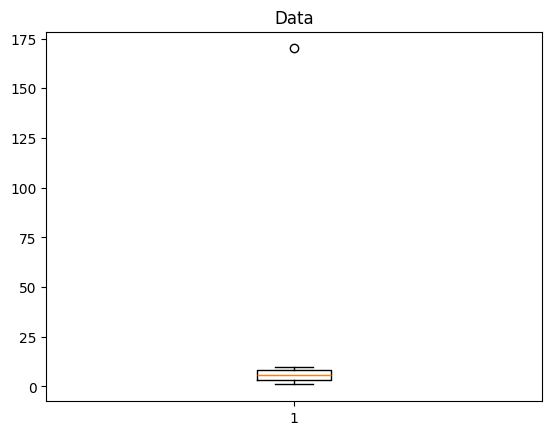

In [13]:
plt.boxplot(d)
plt.title('Data')
plt.show()

In [14]:
print(skew(d))

2.828627197307549


## Handling the outlier by replacing

In [21]:
for i in range(len(d)):
    if d[i]>upper or d[i]<lower:
        d[i]=q2
print(d)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 6]


# Probability Distributions

## Normal Distribution

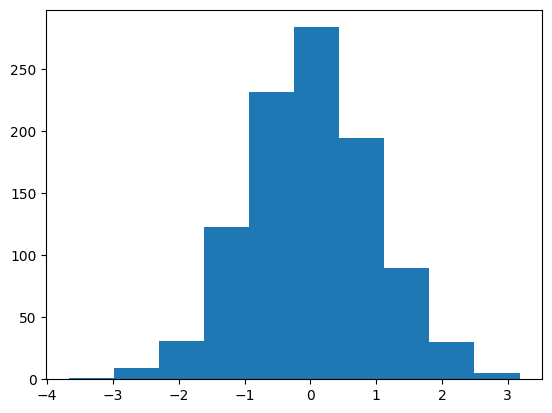

In [22]:
nd=np.random.normal(0,1,1000)
plt.hist(nd)
plt.show()

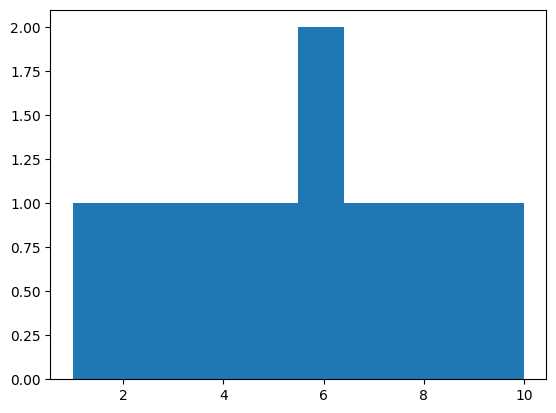

In [23]:
plt.hist(d)
plt.show(d)

# Finding the probability

## Using Conditional Probability

In [17]:
# P_A_given_B
# Total Students = 20
# Total Boys = 5
# Boys passed = 2
# Find probability of boy
B=5
B_Passed=2
P_B_Given_B_Passed=B_Passed/B
print(P_B_Given_B_Passed)

0.4


## Using Bayes Theorem

In [18]:
# Probability of D = 0.01
# Probability of Pos given D = 0.9
# Probability of Positive given No D = 0.1
P_D = 0.01
P_Pos_Given_D = 0.9
P_Pos_Given_No_D = 0.1
P_No_D = 1-P_D
# Find P(D|Pos)
# P(D|Pos) = [P(Pos|D)*P(D)]/P(Pos)
P_Pos=P_Pos_Given_D*P_D + P_Pos_Given_No_D*P_No_D
P_D_Given_Pos= (P_Pos_Given_D*P_D)/P_Pos
print(P_D_Given_Pos)

0.08333333333333333
